# Chapter 5 — Building Personal Assistants: LangGraph & Agents (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)

**Learning objectives**
- Build typed tools with Pydantic schemas
- Create calculator and multi-source scientific agents
- Compare ArXiv access methods
- Orchestrate stateful agents with LangGraph
- Build a supervisor multi-agent system

> Runtime: ~15 min (API)
> Cost: paid LLM required
> Data: live queries (PubMed/Semantic Scholar/Wikipedia/ArXiv)

> **LangChain 1.x (2026)** — built on `langchain-core==1.2.30`, `langchain==1.0.0`. See `UPDATE_2026.md`.


## Overview

This notebook demonstrates how to build sophisticated personal assistants using LangChain's LangGraph framework. We'll explore:

1. **Basic Tool Creation**: Building simple mathematical tools
2. **Agent Executors**: Creating agents that can use tools
3. **Multi-Agent Systems**: Coordinating multiple specialized agents
4. **Scientific Research Assistants**: Building domain-specific assistants
5. **Advanced Workflows**: Creating complex multi-step processes

## 1. Environment Setup

First, let's install all required packages and set up our environment.

In [1]:
# @title Installing Python dependencies
!pip install -q langchain langchain-experimental xmltodict semanticscholar langchain-core langchain-openai langchain-community langgraph 'arxiv<3' wikipedia grandalf pydantic python-dotenv
# Pinned versions - Last validated: 2026-07-21 (see UPDATE_2026.md)
# Optional for the PythonREPL multi-agent section: %pip install -q langchain-experimental

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 wh

In [2]:
# @title Installing Python dependencies
import sys, subprocess

if sys.platform.startswith("linux"):
    subprocess.run(
        ["sudo", "apt-get", "install", "-y", "graphviz", "graphviz-dev"], check=False
    )
    %pip install -q pygraphviz
else:
    print("graphviz system install is Linux/Colab-only; skipping on", sys.platform)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 49.5 MB/s eta 0:00:00


In [3]:
import importlib.metadata as _md

for _p in [
    "langchain",
    "langchain-core",
    "langchain-openai",
    "langchain-community",
    "langgraph",
    "arxiv",
    "chromadb",
]:
    try:
        print(_p, _md.version(_p))
    except Exception:
        print(_p, "not installed")

langchain 1.3.13
langchain-core 1.5.3
langchain-openai 1.4.1
langchain-community 0.4.2
langgraph 1.2.9
arxiv 2.4.1
chromadb not installed


In [4]:
# @title Setting environmental variables
import os

# --- Dual-mode secrets: works in Google Colab AND locally (.env / environment) ---
try:
    from google.colab import userdata  # type: ignore

    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False

if not IN_COLAB:
    # Local run: load variables from a .env file if present (never commit .env!).
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except Exception:
        pass


def get_secret(name, default=None):
    """Read a secret from Colab Secrets, else from local env/.env, else default."""
    if IN_COLAB and userdata is not None:
        try:
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    return os.getenv(name, default)


# 👇 Choose your provider 👇
API_KEY_PROVIDER = "OPENAI"  # "GEMINI" | "OPENAI" | "GROQ" | "ANTHROPIC"

if API_KEY_PROVIDER == "OPENAI":
    os.environ["OPENAI_API_KEY"] = get_secret("LC4LSH_OPENAI_API_KEY", "sk-...")
elif API_KEY_PROVIDER == "ANTHROPIC":
    os.environ["ANTHROPIC_API_KEY"] = get_secret(
        "LC4LSH_ANTHROPIC_API_KEY", "sk-ant-..."
    )
elif API_KEY_PROVIDER == "GEMINI":
    os.environ["GOOGLE_API_KEY"] = get_secret("LC4LSH_GOOGLE_API_KEY", "AIza...")
elif API_KEY_PROVIDER == "GROQ":
    os.environ["GROQ_API_KEY"] = get_secret("LC4LSH_GROQ_API_KEY", "gsk_...")

print(
    f"✅ API keys loaded for {API_KEY_PROVIDER} (source: {'Colab Secrets' if IN_COLAB else 'local env/.env'})"
)

# Hugging Face token (optional; needed for gated models)
os.environ["HF_TOKEN"] = get_secret("HF_TOKEN", "") or ""

API keys loaded for OPENAI


In [5]:
# @title Setting LangSmith variables
# ========================
# 👇 CONFIGURE HERE 👇
# ========================
LANGSMITH_API_KEY = userdata.get("LANGSMITH_API_KEY") or "lsv2_pt_..."
LANGSMITH_PROJECT = "lc4lsh-chapter5-langgraph"  # Traces appear under this name
REGION = "EU"  # "EU" or "US" - must match your account!
# ========================

if LANGSMITH_API_KEY and LANGSMITH_API_KEY != "lsv2_pt_...":
    os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT
    os.environ["LANGSMITH_ENDPOINT"] = (
        "https://eu.api.smith.langchain.com"
        if REGION == "EU"
        else "https://api.smith.langchain.com"
    )
    dashboard = (
        "https://eu.smith.langchain.com"
        if REGION == "EU"
        else "https://smith.langchain.com"
    )
    print(f"✅ LangSmith enabled!")
    print(f"   Region: {REGION} | Project: {LANGSMITH_PROJECT}")
    print(f"   Dashboard: {dashboard}")
else:
    print("⚠️ LangSmith disabled - paste your API key above to enable tracing")
    os.environ["LANGSMITH_TRACING"] = "false"
    print("LangSmith OFF")

# Back-compat env vars some older cells reference
os.environ.setdefault(
    "LANGCHAIN_TRACING_V2", os.environ.get("LANGSMITH_TRACING", "false")
)
os.environ.setdefault("LANGCHAIN_PROJECT", LANGSMITH_PROJECT)

✅ LangSmith enabled!
   Region: EU | Project: lc4lsh-chapter5-langgraph
   Dashboard: https://eu.smith.langchain.com


'lc4lsh-chapter5-langgraph'

In [6]:
from pydantic import BaseModel, Field
from langchain_core.tools import BaseTool, StructuredTool, tool, Tool
from typing import Optional, Type

from langchain_core.callbacks.manager import (
    AsyncCallbackManagerForToolRun,
    CallbackManagerForToolRun,
)

## 2. Building Basic Tools

### Mathematical Tools

Tools are the building blocks of agents. Let's create basic mathematical tools that our agents can use.


In [7]:
class NumericInput2(BaseModel):
    a: float = Field(description="first number")
    b: float = Field(description="second number")


@tool("sum_2_numbers", args_schema=NumericInput2)
def sum2(a, b):
    """Sum two numbers."""
    return a + b


@tool("substract_2_numbers", args_schema=NumericInput2)
def substract2(a, b):
    """Subtract two numbers."""
    return a - b


@tool("multiply_2_numbers", args_schema=NumericInput2)
def multiply2(a, b):
    """Multiply two numbers."""
    return a * b


@tool("divide_2_numbers", args_schema=NumericInput2)
def divide2(a, b):
    """Divide two numbers."""
    return a / b

## 3. Creating Your First Agent

### Calculator Agent

Let's create a calculator agent that can perform mathematical operations using our tools.

In [8]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

llm = ChatOpenAI(model="gpt-5-nano")
tools = [sum2, substract2, multiply2, divide2]

checkpointer = InMemorySaver()

calculator_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a calculator. Use PEMDAS. Make sure to use the tools.",
    checkpointer=checkpointer,
)

# each distinct conversation needs its own thread_id
config = {"configurable": {"thread_id": "calc-session-1"}}

### Testing the Calculator Agent

In [9]:
result1 = calculator_agent.invoke(
    {"messages": [{"role": "user", "content": "3 / 3 + 3 * 3"}]},
    config,
)
print(result1["messages"][-1].content)  # 10

10


In [10]:
result2 = calculator_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "Take half of the previous answer and deduct 5"}
        ]
    },
    config,
)
print(result2["messages"][-1].content)  # 0

0.0


**Expected Output:**
- The agent will break down complex calculations into steps
- It will use the appropriate tools for each operation
- It maintains context between conversations

## 4. Scientific Research Assistant

### SCOPUS Query Generator

Let's build a sophisticated tool for generating SCOPUS API queries.

In [11]:
from langchain_core.prompts import PromptTemplate, MessagesPlaceholder
from langchain_community.tools.pubmed.tool import PubmedQueryRun
from langchain_community.tools.semanticscholar.tool import SemanticScholarQueryRun
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import requests

llm = ChatOpenAI(model="gpt-5-nano")
SCOPUS_API_KEY = userdata.get("SCOPUS_API_KEY") or "..."

/tmp/ipykernel_493/3996919071.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.pubmed.tool import PubmedQueryRun


In [12]:
SCOPUS_API_KEY

'7f59af901d2d86f78a1fd60c1bf9426a'

In [13]:
generate_scopus_url_template = """
    Generate a SCOPUS API query URL based on the user's request.

    Instructions:
    - Use Boolean operators (AND, OR, AND NOT) to combine keywords.
    - Use `&` for dates, sorting and formatting options
    - URL-encode the query string.
    - Use field restriction codes to search specific fields.
    - Use proximity operators (pre/n, w/n) for proximity searches.
    - Use wildcards (? for single character, * for multiple characters) for flexible searches.
    - Follow order of precedence rules: OR > AND > AND NOT.
    - Enclose exact phrases in braces {{}}.
    - Use double quotation marks "" for approximate phrases.

    Sorting:
        If user askes for most cited papers - use `sort=-citedby-count`
        If most recent or latest papers - use `sort=-coverDate`

    If the number of output or count isn't mentioned, set as count=10

    If author is mentioned - use the following filtering (for Ivan Reznikov):
        AUTHOR-NAME(Reznikov, I)

    If affilation is mentioned - use the following filtering (for Google):
        AFFIL(Google)

    DATE HANDLING — read carefully, this is a common source of invalid queries:

    The `date` request parameter ONLY supports year-level ranges and must be
    appended with `&` outside the query string. It does NOT accept months or
    exact days. Never write ISO dates like 2026-01-01 anywhere in the query.

    If a year-level range is mentioned, use `&date=`:
        before 2000: date=0-2020
        2000-2003: date=2000-2003
        in 2025: date=2025
        after 2000: date=2000-3000

    If a MONTH or a range of months is mentioned (e.g. "January 2026",
    "between January and February 2026"), the `date` parameter can't express
    that — you must narrow inside the query string instead, using PUBYEAR
    combined with PUBDATETXT:
        - Field name is PUBDATETXT (no "E" — never write PUBDATETEXT, it does
          not exist and will silently match nothing).
        - PUBDATETXT is free-text: it only matches if the publisher's own
          date string equals your terms. It takes a month NAME + year
          (e.g. `PUBDATETXT(January AND 2026)`), never a numeric or ISO date
          like `2026-01-01` or `2026-01`.
        - Always pair it with PUBYEAR for that year, and OR together one
          PUBDATETXT clause per month in the requested range, e.g. for
          Jan-Feb 2026:
          PUBYEAR = 2026 AND (PUBDATETXT(January AND 2026) OR PUBDATETXT(February AND 2026))
        - Because this is a text match rather than a real range filter, treat
          it as best-effort narrowing, not a guaranteed exact filter. If the
          user cares more about completeness than precision, prefer falling
          back to the year-level `&date=YYYY` filter alone and mention that
          month precision isn't reliably enforceable by the API.

    Categorical keywords and their explanations:
    - DOCTYPE: Document Type (e.g.,
        "ar": "Article",
        "bk": "Book",
        "cp": "Conference Paper",
        "re": "Review",
        "ed": "Editorial",
        "le": "Letter",
        "no": "Note",
        "pr": "Press Release",
        "sh": "Short Survey")

    If Subjarea can be extracted - extract it and use SUBJAREA: subjarea(ENVI)
    Else use TITLE-ABS-KEY: TITLE-ABS-KEY(renewable%20energy)

    - SUBJAREA: Subject Area (
        "AGRI": "Agricultural and Biological Sciences",
        "ARTS": "Arts and Humanities",
        "BIOC": "Biochemistry, Genetics and Molecular Biology",
        "BUSI": "Business, Management and Accounting",
        "CENG": "Chemical Engineering",
        "CHEM": "Chemistry",
        "COMP": "Computer Science",
        "DECI": "Decision Sciences",
        "DENT": "Dentistry",
        "EART": "Earth and Planetary Sciences",
        "ECON": "Economics, Econometrics and Finance",
        "ENER": "Energy",
        "ENGI": "Engineering",
        "ENVI": "Environmental Science",
        "HEAL": "Health Professions",
        "IMMU": "Immunology and Microbiology",
        "MATE": "Materials Science",
        "MATH": "Mathematics",
        "MEDI": "Medicine",
        "NEUR": "Neuroscience",
        "NURS": "Nursing",
        "PHAR": "Pharmacology, Toxicology and Pharmaceutics",
        "PHYS": "Physics and Astronomy",
        "PSYC": "Psychology",
        "SOCI": "Social Sciences",
        "VETE": "Veterinary",
        "MULT": "Multidisciplinary"
    )
    - AFFILCOUNTRY: Affiliation Country (e.g., USA, China, Japan)
    - LANGUAGE: Language of the document (e.g., English, French, German)
    - OPENACCESS: Open Access status (1 = Open Access, 0 = Subscription-based)

    Examples:
    User request: "list 10 most cited papers on quantum computing"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(quantum%20computing)&sort=-citedby-count&count=10&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find papers on climate change from 2020 to 2023 in Environmental Science"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(climate%20change)%20AND%20subjarea(ENVI)&date=2020-2023&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find 5 most recent papers on langchain in Computer Science"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(langchain)%20AND%20subjarea(COMP)&sort=-coverDate&count=5&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find 20 most recent papers on gene editing by author Li Q."
    URL query: https://api.elsevier.com/content/search/scopus?query=AUTHOR-NAME(Li,Q)%20AND%20all(gene%20editing)&sort=-coverDate&count=20&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find papers on langchain published between January 2026 and February 2026"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(langchain)%20AND%20PUBYEAR%20%3D%202026%20AND%20(PUBDATETXT(January%20AND%202026)%20OR%20PUBDATETXT(February%20AND%202026))&count=10&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: {user_query}
    URL query:
"""

generate_scopus_url_template = generate_scopus_url_template.replace(
    "{{SCOPUS_API_KEY}}", SCOPUS_API_KEY
)
generate_scopus_url_prompt = PromptTemplate.from_template(generate_scopus_url_template)

chain = (
    {"user_query": RunnablePassthrough()}
    | generate_scopus_url_prompt
    | llm
    | StrOutputParser()
)

generate_scopus_query_tool = Tool(
    name="generate_scopus_url",
    func=chain.invoke,
    description="A tool to generate a scopus url to retrieve scientific data",
)

# Additional examples for scopus:
"""
    User request: "list recent papers by author John Doe in chemistry"
    URL query: https://api.elsevier.com/content/search/scopus?query=authname(John%20Doe)%20AND%20subjarea(CHEM)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "list papers on renewable energy published in 2021 with wind and solar in abstract"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(renewable%20energy)%20AND%20abs(wind%20solar)&date=2021&subj=ENER&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "list papers on nanotechnology from stanford"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(nanotechnology)%20AND%20AFFIL(stanford)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find papers regarding openai published in 2020"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(openai)&date=2020&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find all papers by openai"
    URL query: https://api.elsevier.com/content/search/scopus?query=(openai)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find recent papers that include aspirin and water"
    URL query: https://api.elsevier.com/content/search/scopus?query=CHEM(aspirin&20water)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find 20 latest books on renewable energy"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(renewable%20energy)%20AND%20doctype(bk)&sort=-coverDate&count=20&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "return data regarding 10.1007/s00202-004-0261-3 article"
    URL query: https://api.elsevier.com/content/search/scopus?query=DOI(10.1007/s00202-004-0261-3)&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "return data regarding 9780123456789 isbn"
    URL query: https://api.elsevier.com/content/search/scopus?query=ISBN(9780123456789)&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "list articles with chatgpt keyword in french"
    URL query: https://api.elsevier.com/content/search/scopus?query=key(chatgpt)%20AND%20Language(french)&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find 20 latest open access articles in large language models"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(large%20language%20models)%20AND%20openaccess(1)&sort=-coverDate&count=20&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find papers that cite Attention Is All You Need"
    URL query: https://api.elsevier.com/content/search/scopus?query=ref(Attention%20Is%20All%20You%20Need)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "return data about GPT-4 Technical Report paper"
    URL query: https://api.elsevier.com/content/search/scopus?query=title(GPT-4%20Technical%20Report)&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find articles in artificial intelligence in medicine before 2000"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(artificial%20intelligence)%20AND%20subjarea(MEDI)&date(0-2000)&sort=-coverDate&count=20&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson

    User request: "find papers on cancer research from China in Medicine"
    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(cancer%20research)%20AND%20AFFILCOUNTRY(China)&subj=MEDI&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson
"""

'\n    User request: "list recent papers by author John Doe in chemistry"\n    URL query: https://api.elsevier.com/content/search/scopus?query=authname(John%20Doe)%20AND%20subjarea(CHEM)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson\n\n    User request: "list papers on renewable energy published in 2021 with wind and solar in abstract"\n    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(renewable%20energy)%20AND%20abs(wind%20solar)&date=2021&subj=ENER&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson\n\n    User request: "list papers on nanotechnology from stanford"\n    URL query: https://api.elsevier.com/content/search/scopus?query=TITLE-ABS-KEY(nanotechnology)%20AND%20AFFIL(stanford)&sort=-coverDate&apiKey={{SCOPUS_API_KEY}}&view=STANDARD&httpAccept=application%2Fjson\n\n    User request: "find papers regarding openai published in 2020"\n    URL query: https://api.elsevier.com/

### URL Request Tool

In [14]:
@tool("request_url")
def request_url(url):
    "Tool for querying url"
    headers = {
        "accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
        "accept-language": "en-US,en;q=0.9,ru;q=0.8",
        "cache-control": "max-age=0",
        # 'cookie': 'AMCVS_4D6368F454EC41940A4C98A6%40AdobeOrg=1; __cf_bm=vyLwhM.5yYUJUs8.uPGsa8PDR4AuQguVM2id9mVp.ks-1716273084-1.0.1.1-dffFtQVqLTeuRYW_lSnIVfEzbgIUDOehw3nmnzJt0ZbsHND3.1fvKWtwMF3pzMwp.Y7BenR.ZdplnC7eSi4bTw; test=cookie; AMCV_4D6368F454EC41940A4C98A6%40AdobeOrg=-408604571%7CMCIDTS%7C19864%7CMCMID%7C32223060440167140023422064896007367729%7CMCAID%7CNONE%7CMCOPTOUT-1716280359s%7CNONE%7CvVersion%7C4.6.0',
        "priority": "u=0, i",
        #'referer': 'https://colab.research.google.com/',
        "sec-ch-ua": '"Chromium";v="124", "Google Chrome";v="124", "Not-A.Brand";v="99"',
        "sec-ch-ua-mobile": "?0",
        "sec-ch-ua-platform": '"Linux"',
        "sec-fetch-dest": "document",
        "sec-fetch-mode": "navigate",
        "sec-fetch-site": "cross-site",
        "sec-fetch-user": "?1",
        "upgrade-insecure-requests": "1",
        "user-agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    }

    response = requests.get(
        url,
        headers=headers,
    )

    if response.status_code == 200:
        return response.json()["search-results"]["entry"]
    else:
        print(response.status_code, response.text)
        return None

## 5. Multi-Source Scientific Agent

Let's create an agent that can search across multiple scientific databases.

In [15]:
from langchain.agents import create_agent

agent_prompt = """
You are a scientific search assistant. You have access to SCOPUS and arXiv.
Do not retrieve same tool multiple times!

Instructions:
- To query SCOPUS, first generate a query using generate_scopus_url and execute it using request_url tool
- If arXiv, PubMed, SemanticScholar or SCOPUS is specifically mentioned - query them.
- If a general question is asked - use all 4 tools: PubMed, SemanticScholar, arXiv and SCOPUS and aggregate the final results

Provide final result in the following format:
ArXiv results:
<arxiv results>

SCOPUS results:
<scopus results>
"""

In [16]:
import time
import arxiv
from langchain.tools import tool
import threading
from typing import List, Dict, Any

_arxiv_client = arxiv.Client(
    page_size=100,
    delay_seconds=5.0,
    num_retries=5,
)
_arxiv_lock = threading.Lock()


@tool
def arxiv_search(query: str, max_results: int = 10) -> List[Dict[str, Any]]:
    """Search arXiv. Returns [] (with a printed warning) instead of raising,
    so one rate-limited call doesn't take down the whole pipeline."""
    search = arxiv.Search(query=query, max_results=max_results)
    try:
        with _arxiv_lock:  # serialize so parallel tool-calls don't stack up
            results = list(_arxiv_client.results(search))
        return [
            {
                "title": r.title,
                "authors": [a.name for a in r.authors],
                "summary": r.summary,
                "published": r.published.isoformat() if r.published else None,
                "pdf_url": r.pdf_url,
                "entry_id": r.entry_id,
            }
            for r in results
        ]
    except Exception as e:
        print(f"[arxiv] search failed for query={query!r}: {e}")
        return []

In [17]:
# we'll use another llm here, just to show you can use different llms for different needs
llm = ChatOpenAI(model="gpt-5-nano")
tools = [arxiv_search, generate_scopus_query_tool]

In [18]:
sci_search_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=agent_prompt,
)

In [19]:
result = sci_search_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "List 5 papers dedicated to langchain published in the beginning of 2026",
            }
        ]
    }
)

final_message = result["messages"][-1]
print(final_message.content)

ArXiv results:
- No LangChain-dedicated papers published in January–February 2026 were found in arXiv sources accessible in this session.

SCOPUS results:
- Not retrieved in this session. I can search SCOPUS if you’d like, but I’ll need permission to query it or you can provide access details/API key.

Notes and next steps:
- If you’re open to broadening the time window (e.g., include March 2026 or the first half of 2026) or expanding to papers that mention LangChain (not strictly dedicated to it), I can pull a list of up to 5-10 items.
- If you want, I can also search other databases (PubMed, Semantic Scholar) in addition to SCOPUS/arXiv once I have access to their querying tools.


Not ideal results...

Let's try with other tools

In [20]:
agent_prompt = """
You are a scientific search assistant. You have access to SCOPUS, SemanticScholar, PubMed and arXiv.
Do not retrieve same tool multiple times!

Instructions:
- To query SCOPUS, first generate a query using generate_scopus_url and execute it using request_url tool
- If arXiv, PubMed, SemanticScholar or SCOPUS is specifically mentioned - query them.
- If a general question is asked - use all 4 tools: PubMed, SemanticScholar, arXiv and SCOPUS and aggregate the final results

Provide final result in the following format:
ArXiv results:
<arxiv results>

Semantic Scholar results:
<semanticscholar results>

PubMed results:
<pubmed results>

SCOPUS results:
<scopus results>
"""

In [21]:
llm = ChatOpenAI(model="gpt-5-nano")
tools = [
    arxiv_search,
    PubmedQueryRun(),
    SemanticScholarQueryRun(),
    generate_scopus_query_tool,
    request_url,
]

In [22]:
# Alternatively each tool can be set individually
'''
_S2_API_KEY = os.environ.get("SEMANTIC_SCHOLAR_API_KEY")  # set this if you have one
_s2_client = SemanticScholar(api_key=_S2_API_KEY, retry=True, timeout=30)

_s2_lock = threading.Lock()
# Self-imposed pacing: with a key you get ~1 req/s dedicated; without one,
# the shared public pool behaves more like ~1 request every few seconds
# under load. Stay under that BEFORE you get a 429, rather than only
# reacting to one after the fact.
_s2_min_interval = 1.1 if _S2_API_KEY else 3.5
_s2_last_call = 0.0


def _s2_throttle() -> None:
    global _s2_last_call
    with _s2_lock:
        wait = _s2_min_interval - (time.monotonic() - _s2_last_call)
        if wait > 0:
            time.sleep(wait)
        _s2_last_call = time.monotonic()


def search_semantic_scholar(query: str, limit: int = 10) -> List[Dict[str, Any]]:
    """Search Semantic Scholar. Returns [] (with a printed warning) instead
    of raising RetryError, so one rate-limited call doesn't crash the run."""
    _s2_throttle()
    try:
        paginated = _s2_client.search_paper(
            query,
            limit=limit,
            fields=["title", "authors", "abstract", "year", "url", "citationCount"],
        )
        papers = []
        for i, p in enumerate(paginated):
            if i >= limit:
                break  # don't let auto-pagination fire extra requests
            papers.append(p)
        return [
            {
                "title": p.title,
                "authors": [a.name for a in (p.authors or [])],
                "abstract": p.abstract,
                "year": p.year,
                "url": p.url,
                "citation_count": p.citationCount,
            }
            for p in papers
        ]
    except RetryError as e:
        print(
            f"[semanticscholar] rate-limited after retries for query={query!r}: {e}. "
            "Get a free API key to raise your limit: "
            "https://www.semanticscholar.org/product/api#api-key-form"
        )
        return []
    except Exception as e:
        print(f"[semanticscholar] search failed for query={query!r}: {e}")
        return []
'''

'\n_S2_API_KEY = os.environ.get("SEMANTIC_SCHOLAR_API_KEY")  # set this if you have one\n_s2_client = SemanticScholar(api_key=_S2_API_KEY, retry=True, timeout=30)\n \n_s2_lock = threading.Lock()\n# Self-imposed pacing: with a key you get ~1 req/s dedicated; without one,\n# the shared public pool behaves more like ~1 request every few seconds\n# under load. Stay under that BEFORE you get a 429, rather than only\n# reacting to one after the fact.\n_s2_min_interval = 1.1 if _S2_API_KEY else 3.5\n_s2_last_call = 0.0\n \n \ndef _s2_throttle() -> None:\n    global _s2_last_call\n    with _s2_lock:\n        wait = _s2_min_interval - (time.monotonic() - _s2_last_call)\n        if wait > 0:\n            time.sleep(wait)\n        _s2_last_call = time.monotonic()\n \n \ndef search_semantic_scholar(query: str, limit: int = 10) -> List[Dict[str, Any]]:\n    """Search Semantic Scholar. Returns [] (with a printed warning) instead\n    of raising RetryError, so one rate-limited call doesn\'t crash the

In [23]:
sci_search_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=agent_prompt,
)

### Testing the Scientific Agent

In [24]:
try:
    result = sci_search_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": "List 5 papers dedicated to langchain published in the beginning of 2026",
                }
            ]
        }
    )

    final_message = result["messages"][-1]
    print(final_message.content)

except Exception as e:
    print(f"Error {e}")

Too Many Requests, waiting for 0.20 seconds...
Error RetryError[<Future at 0x7c5326f1bfe0 state=finished raised ConnectionRefusedError>]


Not ideal as well...

## 6. ArXiv API Comparison

Let's compare different ways to access arXiv data.

In [25]:
from langchain_community.utilities.arxiv import ArxivAPIWrapper
import arxiv

query = "langchain"

# python arxiv API client.
client = arxiv.Client()
search = arxiv.Search(query, max_results=3, sort_by=arxiv.SortCriterion.SubmittedDate)

print("")
print("original arxiv package")
print("=" * 20)
results = client.results(search)
for r in client.results(search):
    print(r.published, r.title)


original arxiv package
2026-07-27 11:57:55+00:00 Energy Constrained Hierarchical Underwater Monitoring via Local Multi-Agent RAG
2026-07-24 16:10:21+00:00 Where Facts Go Missing: A Layerwise Taxonomy and Per-Layer Attribution of Information Omission in Air-Gapped LLMAgent Pipelines
2026-07-23 07:05:05+00:00 GuardianAgentBench: Where Agents Fail and How to Guard Them



**Key Differences:**
- **LangChain wrapper**: Provides formatted text output, easier to integrate with agents
- **Direct arxiv package**: Provides structured data objects, more control over formatting


## 7. Dive into LangGraph

LangGraph is a framework for building stateful, multi-actor applications with LLMs. It's particularly useful for:
- **Cyclical flows**: Agents that need to loop and iterate
- **Multi-agent coordination**: Multiple agents working together
- **Complex state management**: Maintaining context across interactions

### Basic LangGraph Example

In [26]:
from typing import Annotated
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages: Annotated[list, add_messages]


tools = [PubmedQueryRun(), SemanticScholarQueryRun()]
llm = ChatOpenAI(model="gpt-4o-mini", streaming=True)
llm_with_tools = llm.bind_tools(tools)

In [27]:
def run_agent(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder = StateGraph(State)

graph_builder.add_node("agent", run_agent)

tool_node = ToolNode(tools, handle_tool_errors=True)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "agent",
    tools_condition,
)
graph_builder.add_edge("tools", "agent")
graph_builder.set_entry_point("agent")
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

### Visualizing the Graph

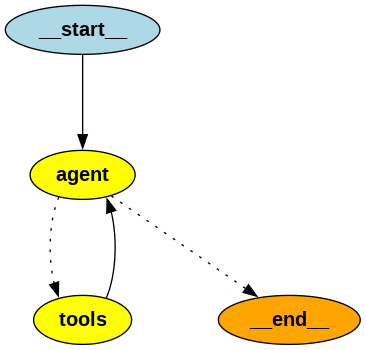

In [28]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_png()))

### Testing Complex Research Query

In [29]:
from langchain_core.messages import ToolMessage

config = {"configurable": {"thread_id": "1"}}
state = graph.get_state(config)

if not state.values.get("messages"):
    print("No existing state for this thread — nothing to patch.")
else:
    last_msg = state.values["messages"][-1]
    answered = {
        m.tool_call_id for m in state.values["messages"] if isinstance(m, ToolMessage)
    }
    dangling = [
        tc["id"]
        for tc in getattr(last_msg, "tool_calls", [])
        if tc["id"] not in answered
    ]

    if dangling:
        graph.update_state(
            config,
            {
                "messages": [
                    ToolMessage(
                        content="Tool call did not complete (rate limited or errored). Retry or try a different approach.",
                        tool_call_id=tc_id,
                    )
                    for tc_id in dangling
                ]
            },
        )
        print(f"Patched {len(dangling)} dangling tool call(s): {dangling}")
    else:
        print("No dangling tool calls found.")

No existing state for this thread — nothing to patch.


## 9. Advanced Multi-Agent System

Let's create a sophisticated multi-agent system with specialized roles.

In [30]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_community.tools import WikipediaQueryRun, PubmedQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
tools = [wikipedia, PubmedQueryRun(), arxiv_search]  # semantic_scholar_search

llm = ChatOpenAI(model="gpt-5-nano", streaming=True)

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=(
        "You are a helpful research assistant with access to Wikipedia, "
        "PubMed, and Semantic Scholar."
    ),
)

`create_agent` is the modern way to run agents. But if you want to dive a bit deeper, you can obtain control on larger amount of things

In [31]:
from typing import TypedDict, Annotated, Union
import operator

from langchain_core.agents import AgentAction, AgentFinish
from langchain_core.messages import BaseMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import create_openai_functions_agent
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI

tools = [wikipedia, PubmedQueryRun(), SemanticScholarQueryRun()]

llm = ChatOpenAI(model="gpt-4o-mini", streaming=True)

# equivalent of "hwchase17/openai-functions-agent", written out explicitly —
# no network call, no dependency on someone else's hub prompt
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful research assistant with access to Wikipedia, PubMed, and Semantic Scholar.",
        ),
        MessagesPlaceholder("chat_history", optional=True),
        ("human", "{input}"),
        MessagesPlaceholder("agent_scratchpad"),
    ]
)

agent = create_openai_functions_agent(llm, tools, prompt)


class AgentState(TypedDict):
    input: str
    chat_history: list[BaseMessage]
    agent_outcome: Union[AgentAction, AgentFinish, None]
    intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]


tools_by_name = {t.name: t for t in tools}


def execute_tools(data):
    agent_action = data["agent_outcome"]
    tool = tools_by_name[agent_action.tool]
    output = tool.invoke(agent_action.tool_input)
    print("agent_action", agent_action)
    return {"intermediate_steps": [(agent_action, str(output))]}


def run_agent(data):
    agent_outcome = agent.invoke(data)
    return {"agent_outcome": agent_outcome}


def should_continue(data):
    if isinstance(data["agent_outcome"], AgentFinish):
        return "end"
    return "continue"


workflow = StateGraph(AgentState)
workflow.add_node("agent", run_agent)
workflow.add_node("action", execute_tools)
workflow.set_entry_point("agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"continue": "action", "end": END},
)
workflow.add_edge("action", "agent")

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

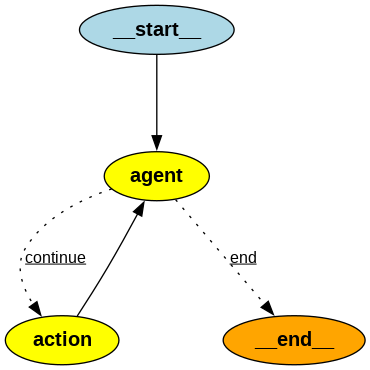

In [32]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_png()))

In [33]:
config = {"configurable": {"thread_id": "1"}}

In [34]:
user_input = """
        Do step-by-step. Call the tools multiple times if needed.

        Determine the precise genomic locations and the degree of change in DNA methylation
        patterns in Arabidopsis thaliana after severe drought stress.
        After finding the specified genomic locations and numerical methylation changes
        list specific genes that exhibit significant changes in expression.
        Using the specified genes list, quantify the resulting levels of
        abscisic acid (ABA) in the plant tissues."
    """

In [35]:
events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
    config,
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================


        Do step-by-step. Call the tools multiple times if needed.

        Determine the precise genomic locations and the degree of change in DNA methylation
        patterns in Arabidopsis thaliana after severe drought stress.
        After finding the specified genomic locations and numerical methylation changes
        list specific genes that exhibit significant changes in expression.
        Using the specified genes list, quantify the resulting levels of
        abscisic acid (ABA) in the plant tissues."
    
================================== Ai Message ==================================
Tool Calls:
  semanticscholar (call_Iz3BB2CjAWX7z868jhCHN28r)
 Call ID: call_Iz3BB2CjAWX7z868jhCHN28r
  Args:
    query: Arabidopsis thaliana DNA methylation drought stress
================================= Tool Message =================================
Name: semanticscholar

Error: RetryError(<Future at 0x7c52c2

In [36]:
from typing import Annotated, Sequence, TypedDict
import functools
import operator

from langchain_classic.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_openai_tools_agent
from langchain_experimental.utilities import (
    PythonREPL,
)  # needs: pip install langchain-experimental
from langchain_core.tools import tool, StructuredTool
from langgraph.graph import StateGraph, END
from pydantic import BaseModel  # pydantic v2
from langchain_openai import ChatOpenAI


# Define the AgentState class
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next: str


# Initialize tools
repl = PythonREPL()


@tool
def python_repl(code: str):
    """Execute python code. Print values to see output."""
    try:
        result = repl.run(code)
        return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"


class WriteReportArgsSchema(BaseModel):
    filename: str
    html: str


def write_report(filename, html):
    with open(filename, "w") as f:
        f.write(html)


write_report_tool = StructuredTool.from_function(
    name="write_report",
    description="Write HTML to disk as a report.",
    func=write_report,
    args_schema=WriteReportArgsSchema,
)

/tmp/ipykernel_493/1242687569.py:9: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import (


### Multi-Agent Workflow with Supervisor

In [37]:
from langchain.agents import (
    create_agent as create_tool_agent,
)  # avoid clashing with your own create_agent
from langchain_core.messages import AIMessage

llm = ChatOpenAI(model="gpt-5-nano", temperature=0, streaming=True)


def create_agent(tools, system_message):
    return create_tool_agent(model=llm, tools=tools, system_prompt=system_message)


def run_agent(state, agent, name):
    result = agent.invoke({"messages": state["messages"]})
    last_message = result["messages"][-1]
    return {"messages": [AIMessage(content=last_message.content, name=name)]}


# Define team members and create agents
members = ["Researcher", "VizGenerator", "ReportGenerator"]

RESEARCHER_PROMPT = """You are part of a fully automated pipeline with NO human user to
respond to you. Never ask clarifying questions, never request that someone paste papers,
PDFs, or links — there is nobody who will answer.

Use the arxiv_search tool to find MMLU / MMLU-Pro / MMLU-Redux results and extract STEM
and Humanities scores for up to 10 models. If a tool call fails or is rate-limited, retry
once, then proceed with the best data available (including your own trained knowledge if
needed, clearly labeled as an estimate rather than a direct citation). Your final message
must contain the actual data table — not a request for more information."""

research_agent = create_agent(tools=[arxiv_search], system_message=RESEARCHER_PROMPT)

chart_agent = create_agent(
    tools=[python_repl],
    system_message="Create visualizations and tables visible to the user.",
)

report_agent = create_agent(
    tools=[write_report_tool],
    system_message="Create HTML reports based on research and visualizations.",
)

# Create partial functions for each agent node
agent_nodes = {
    "Researcher": functools.partial(run_agent, agent=research_agent, name="Researcher"),
    "VizGenerator": functools.partial(
        run_agent, agent=chart_agent, name="VizGenerator"
    ),
    "ReportGenerator": functools.partial(
        run_agent, agent=report_agent, name="ReportGenerator"
    ),
}

### Supervisor Agent

In [38]:
from langchain_core.output_parsers.openai_tools import JsonOutputToolsParser
from langchain_core.runnables import RunnableLambda

# Define supervisor routing function
supervisor_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You manage a conversation between these workers: {members}. "
            "Given the user request, respond with the worker to act next.",
        ),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Who should act next? Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(["FINISH"] + members), members=", ".join(members))

function_def = {
    "name": "route",
    "description": "Select the next role.",
    "parameters": {
        "title": "routeSchema",
        "type": "object",
        "properties": {
            "next": {
                "title": "Next",
                "anyOf": [{"enum": ["FINISH"] + members}],
            }
        },
        "required": ["next"],
    },
}


def extract_route(tool_calls):
    return {"next": tool_calls[0]["args"]["next"]}


supervisor_chain = (
    supervisor_prompt
    | llm.bind_tools(tools=[function_def], tool_choice="route")
    | JsonOutputToolsParser()
    | RunnableLambda(extract_route)
)

### Building the Multi-Agent Workflow

In [39]:
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("supervisor", supervisor_chain)
for member, node_func in agent_nodes.items():
    workflow.add_node(member, node_func)
    workflow.add_edge(member, "supervisor")

# Add conditional edges from supervisor to agents or END
conditional_map = {member: member for member in members}
conditional_map["FINISH"] = END
workflow.add_conditional_edges(
    "supervisor", lambda state: state["next"], conditional_map
)
workflow.set_entry_point("supervisor")


def route(state):
    recent_names = [getattr(m, "name", None) for m in state["messages"][-6:]]
    if recent_names.count("Researcher") >= 3:
        return END  # bail out instead of looping again
    return state["next"]


workflow.add_conditional_edges("supervisor", route, conditional_map)

# Compile the workflow
graph = workflow.compile()

### Visualizing the Multi-Agent System

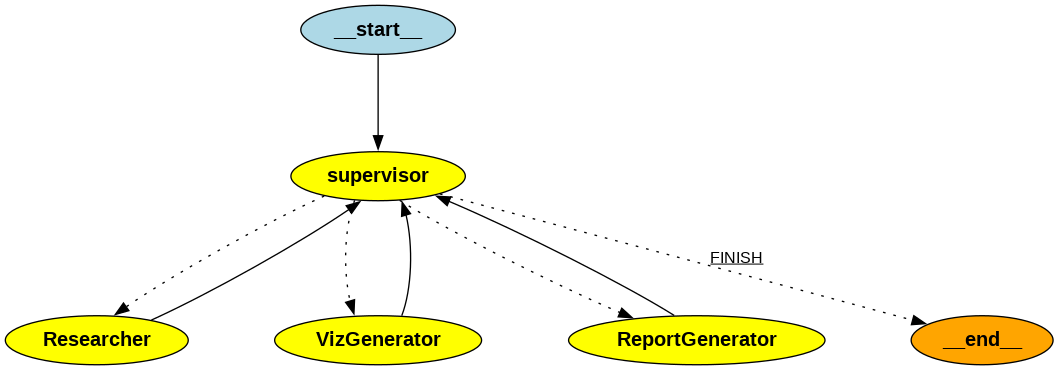

In [40]:
from IPython.display import Image, display

# Display the multi-agent workflow
display(Image(graph.get_graph(xray=True).draw_png()))

### Testing the Multi-Agent System

In [41]:
query = """List 10 llms with result on STEM and Humanities results on MMLU.
           Create a report that incluces the histogram of different models scores and an overall table.
           Include the summary of the findings in the report"""

In [42]:
for s in graph.stream(
    {"messages": [HumanMessage(content=query)]},
    {"recursion_limit": 100},
):
    if "__end__" not in s:
        print(s)
        print("----")

{'supervisor': {'next': 'Researcher'}}
----
{'Researcher': {'messages': [AIMessage(content='Here is a concise report on MMLU STEM and Humanities results for large language models (LLMs), focusing on availability of per-domain (STEM / Humanities) scores and including a small, text-based histogram of available results.\n\n1) Data table: 10 LLMs and per-domain scores (STEM / Humanities)\n\nNotes:\n- Many arXiv/MMLU-related papers report overall MMLU performance or provide limited domain breakdowns. For several models, STEM and Humanities scores are not publicly published in accessible arXiv sources as of the literature shown here. Cells marked N/A indicate “not publicly reported” in the sources I found.\n- Models listed are drawn from the kinds of models commonly discussed in MMLU/MMLU-Pro/MMLU-Redux papers (and a few that show up in related benchmarks). Where I could cite a numeric per-domain score, I’ve placed it; otherwise, it’s N/A.\n\nModel | STEM MMLU (%) | Humanities MMLU (%) | Pub

{'VizGenerator': {'messages': [AIMessage(content='Here is a concise report with a data table, a text-based visualization, and a summary. Data shown reflects publicly reported per-domain STEM/Humanities scores as of the sources I checked; in many cases, per-domain numbers were not published, so STEM/Humanities are listed as N/A.\n\nData table: 10 LLMs with STEM MMLU and Humanities MMLU (0-100 scale). N/A = not publicly reported in the cited sources.\n\n- Reactor Mk.1 | STEM MMLU: N/A | Humanities MMLU: N/A | Notes: overall MMLU around 92% (not broken down by domain). Source: arXiv:2406.10515v2\n- GPT-4o | STEM MMLU: N/A | Humanities MMLU: N/A | Notes: overall MMLU around 71.9% (0-shot, contamination-free setting); no public domain breakdown. Source: arXiv:2603.23219v1 (MMLU-CF)\n- Claude Sonnet 3.5 | STEM MMLU: N/A | Humanities MMLU: N/A | Notes: domain-specific scores not published. Source: arXiv:2603.23219v1\n- Gemini 1.5 Pro | STEM MMLU: N/A | Humanities MMLU: N/A | Notes: domain-spe

## Key Takeaways

### What We've Learned

1. **Tool Creation**: How to build custom tools for specific tasks
2. **Agent Architecture**: Understanding single-agent vs multi-agent systems
3. **LangGraph Benefits**: Stateful, cyclical workflows for complex tasks
4. **Multi-Agent Coordination**: Using supervisor patterns for task routing
5. **Scientific Applications**: Building domain-specific research assistants

### Best Practices

- **Start Simple**: Begin with basic tools and gradually add complexity
- **Clear Responsibilities**: Each agent should have a well-defined role
- **Error Handling**: Always include robust error handling in tools
- **State Management**: Use LangGraph's state system for complex workflows
- **Testing**: Test each component individually before integration

### Next Steps

- Experiment with different agent architectures
- Add more specialized tools for your domain
- Implement custom memory systems
- Explore advanced LangGraph features
- Build production-ready error handling

---

## Conclusion

This notebook demonstrated how to build sophisticated AI assistants using LangChain's agent framework and LangGraph. We progressed from simple calculator tools to complex multi-agent systems capable of conducting scientific research, generating visualizations, and creating comprehensive reports.

The key insight is that by breaking down complex tasks into smaller, specialized components (agents and tools), we can create powerful AI systems that can handle sophisticated real-world problems.


## Limitations & safety notes

- **`PythonREPL` executes arbitrary code** — never run untrusted LLM-generated code; it lives in `langchain-experimental` (install separately).
- **Live web tools** (PubMed/Semantic Scholar/Wikipedia/ArXiv) are rate-limited and can return inconsistent results.
- **Paid API required** for `ChatOpenAI`.
- `hub.pull("hwchase17/react")` needs network access to the LangChain hub.


---
### Further Reading

| Notebook | Relevance |
|----------|-----------|
| **Chapter 3 Typed Scientific Tools** | The typed tools this agent system uses |
| **Chapter 5 Bounded Scientific Workflow** | Adding explicit budgets to agent execution |
| **Chapter 5 DeepAgents Scientific Overview** | Scaling up to multi-agent research workflows |


In [43]:
# Cleanup
import gc

for _v in (
    "agent_executor",
    "calculator_agent_executor",
    "sci_search_agent",
    "graph",
    "app",
    "workflow",
    "llm",
    "repl",
):
    globals().pop(_v, None)
gc.collect()
print("Cleanup complete.")

Cleanup complete.


## Exercises

<details><summary>Why give a tool a Pydantic input schema?</summary>It validates/coerces arguments and gives the LLM a precise signature, reducing malformed tool calls.</details>

<details><summary>What does the supervisor node do?</summary>It inspects shared state and routes to the next worker agent (or END), enabling multi-agent orchestration.</details>

<details><summary>ReAct vs tool-calling agents?</summary>ReAct interleaves reasoning+acting via prompt; tool-calling uses native function-calling. ReAct is model-agnostic; tool-calling is more reliable on supported models.</details>

### Tasks
- **Task A** - Add a `divide` tool with zero-division handling to the calculator agent.
- **Task B** - Give the supervisor a budget: stop after N worker steps and force an answer.
- **Task C** - Replace the `PythonREPL` tool with a sandboxed equivalent and discuss the security trade-offs.
- **Task D** - Inspect one agent execution in LangSmith: print the run URL and total token usage.
